# Predicting Volatility of the Global X Uranium ETF (URA) Using an LSTM Network

**Deep Learning Final Project**

This notebook implements an LSTM-based recurrent neural network to predict the realised volatility of the Global X Uranium ETF (URA). The data is sourced directly from Yahoo Finance via the `yfinance` API.


## 1. Imports and Setup

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0
NumPy version: 2.3.3
Pandas version: 2.3.3


In [ ]:
TICKER = "URA"

FEATURE_COLS = ['Log_Return', 'Roll_Mean_5', 'Roll_Mean_21',
                'Roll_Std_5', 'Roll_Std_21', 'Volume_Change',
                'HL_Range', 'OC_Range']

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

WINDOW_SIZE = 30

EPOCHS = 100
LR = 0.001
DROPOUT_RATE = 0.2



## 2. Data Acquisition

We download daily OHLCV (Open, High, Low, Close, Volume) data for the Global X Uranium ETF (URA) from Yahoo Finance. URA tracks companies involved in uranium mining and nuclear energy production. It was launched in November 2010, giving us approximately 15 years of daily trading data.

**Data source:** Yahoo Finance API via the `yfinance` Python library.


In [32]:
# Download URA data from Yahoo Finance
data = yf.download(
    TICKER,       
    period="max",
    auto_adjust=True,
    progress=True
)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Define required columns and check for missing ones
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
missing_cols = [col for col in required_cols if col not in data.columns]
if data.empty:
    raise ValueError('No data was downloaded for URA. Check your internet connection or ticker/date range.')
if missing_cols:
    raise ValueError(f'Missing expected columns from Yahoo Finance: {missing_cols}')

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
print(f"Total trading days: {len(data)}")
print()
data.head(10)


[*********************100%***********************]  1 of 1 completed

Dataset shape: (3878, 5)
Date range: 2010-11-05 to 2026-04-09
Total trading days: 3878



Price,Close,High,Low,Open,Volume
Date,,,,,
2010-11-05,66.739464,66.855802,64.296358,66.855802,48233
2010-11-08,74.185120,74.185120,67.166036,67.670168,255017
2010-11-09,71.742020,77.248702,70.966432,75.077056,334967
2010-11-10,72.866631,73.099308,69.803053,72.362498,121967
2010-11-11,73.487083,73.758543,71.819570,73.680983,111767
2010-11-12,70.345947,72.091026,68.600873,71.897127,59017
2010-11-15,69.221367,72.827860,68.872351,72.827860,26150
2010-11-16,64.102463,67.864071,63.171754,67.864071,124267
2010-11-17,65.769981,65.769981,63.598331,64.451479,46500


## 3. Exploratory Data Analysis

### 3.1 Raw Price and Volume Data

Below we plot the raw closing price and trading volume for URA over its full history. This gives us a sense of the overall trends and periods of high activity.


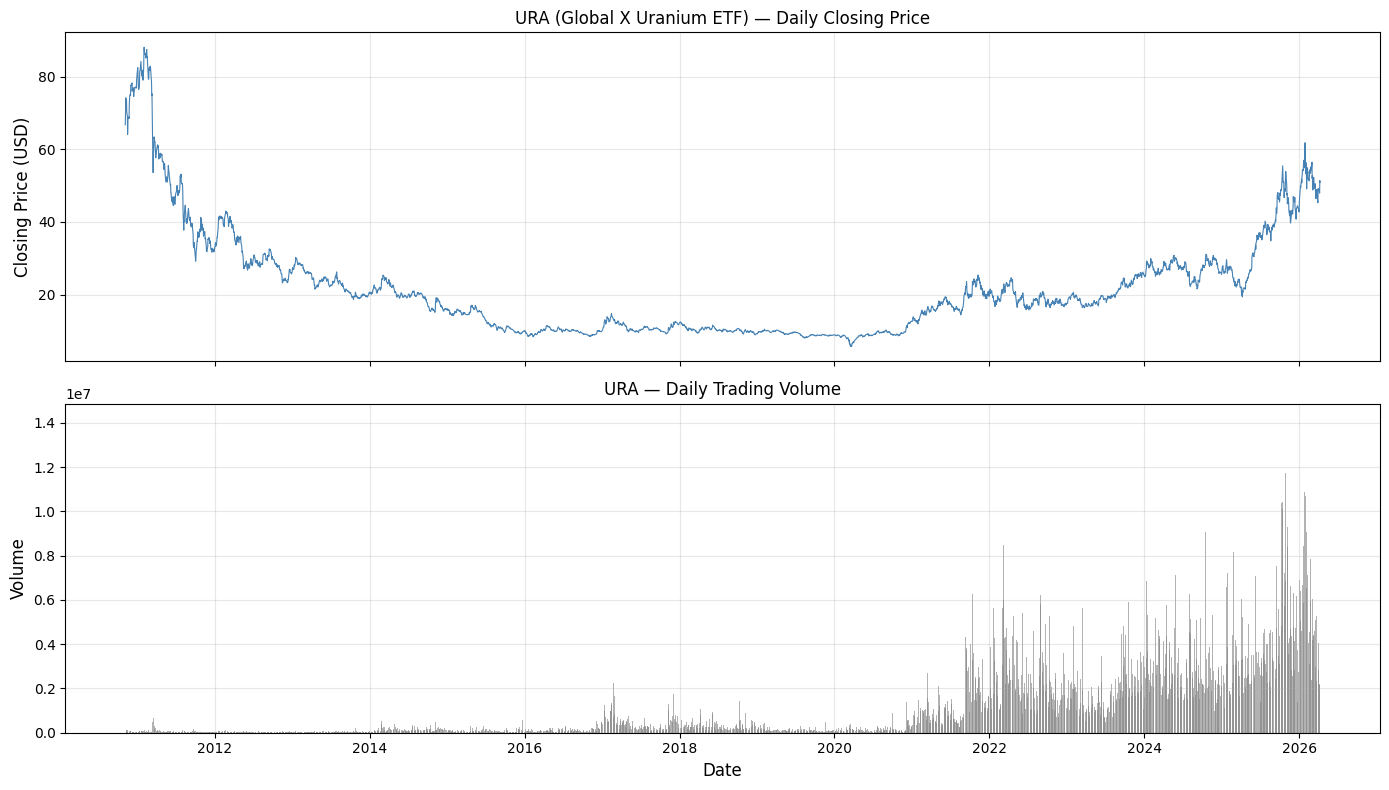

In [33]:
# Plot the daily closing price and volume
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Closing price
axes[0].plot(data.index, data['Close'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Closing Price (USD)', fontsize=12)
axes[0].set_title('URA (Global X Uranium ETF) — Daily Closing Price')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(data.index, data['Volume'], color='grey', alpha=0.6, width=2)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_title('URA — Daily Trading Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Feature Engineering and Preprocessing

### 4.1 Computing Features and Target Variable

We engineer the following features from the raw OHLCV data:

- **Log returns**: $r_t = \ln(C_t / C_{t-1})$ where $C_t$ is the closing price
- **Rolling mean of log returns** (5-day and 21-day windows)
- **Rolling standard deviation of log returns** (5-day and 21-day windows)
- **Volume change**: percentage change in daily volume
- **High-Low range**: $(H_t - L_t) / C_t$, a daily price range normalised by closing price
- **Open-Close range**: $(C_t - O_t) / O_t$

**Target variable**: The **21-day forward realised volatility**, defined as the standard deviation of log returns over the next 21 trading days. This represents approximately one month of trading and is a standard measure of short-term volatility.

$$\sigma_{t,21} = \text{std}(r_{t+1}, r_{t+2}, \ldots, r_{t+21})$$


In [34]:
# Work on a copy so feature engineering leaves the raw download untouched.
df = data.copy()

# --- Compute log returns ---
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# --- Rolling statistics of log returns ---
df['Roll_Mean_5'] = df['Log_Return'].rolling(window=5).mean()
df['Roll_Mean_21'] = df['Log_Return'].rolling(window=21).mean()
df['Roll_Std_5'] = df['Log_Return'].rolling(window=5).std()
df['Roll_Std_21'] = df['Log_Return'].rolling(window=21).std()

# --- Volume change ---
df['Volume_Change'] = df['Volume'].pct_change()

# --- Normalised high-low and open-close ranges ---
df['HL_Range'] = (df['High'] - df['Low']) / df['Close']
df['OC_Range'] = (df['Close'] - df['Open']) / df['Open']

# --- Target: 5-day forward realised volatility ---
df['Target_Vol_5'] = df['Log_Return'].rolling(window=5).std().shift(-5)

# --- Target: 21-day forward realised volatility ---
df['Target_Vol_21'] = df['Log_Return'].rolling(window=21).std().shift(-21)

# Drop rows with NaN values from rolling windows and forward target
df.dropna(inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print()
df[['Log_Return', 'Roll_Std_5', 'Roll_Std_21', 'HL_Range', 'Target_Vol_5', 'Target_Vol_21']].describe()


Dataset shape after feature engineering: (3836, 15)
Date range: 2010-12-07 to 2026-03-10



Price,Log_Return,Roll_Std_5,Roll_Std_21,HL_Range,Target_Vol_5,Target_Vol_21
count,3836.000000,3836.000000,3836.000000,3836.000000,3836.000000,3836.000000
mean,-0.000105,0.019281,0.020853,0.025894,0.019298,0.020914
std,0.022701,0.011226,0.008742,0.014851,0.011233,0.008760
min,-0.190972,0.000793,0.006234,0.003640,0.000793,0.006234
25%,-0.012477,0.011719,0.014820,0.015679,0.011719,0.014873
50%,0.000000,0.016916,0.019257,0.022414,0.016945,0.019319
75%,0.011391,0.023800,0.024404,0.032079,0.023830,0.024514
max,0.125164,0.103781,0.059742,0.171983,0.103781,0.059742


### 4.2 Visualising the Target Variable

The plot below shows the 21-day realised volatility over time. Notice the distinct volatility regimes — long quiet periods followed by sharp spikes, particularly around 2011 (Fukushima), 2020 (COVID), and 2021–2022 (uranium price surge). These regime shifts are what we hope the LSTM can learn to anticipate.


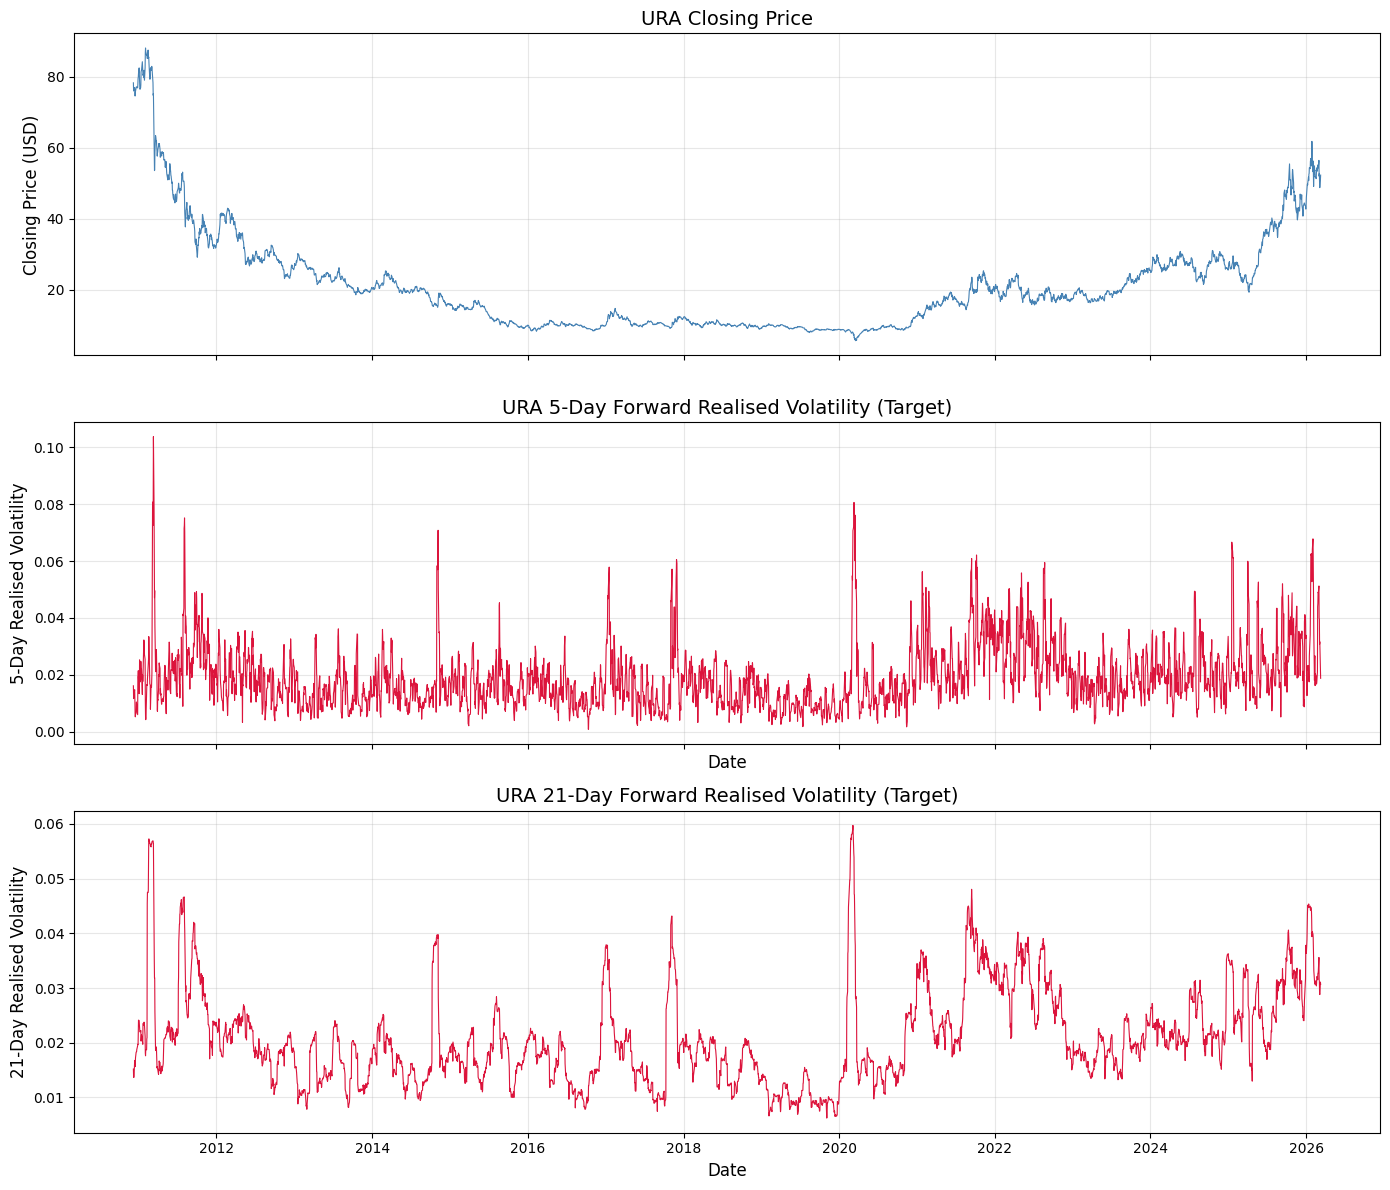

In [35]:
#Plot the closing price and target volatility
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Closing Price (USD)', fontsize=12)
axes[0].set_title('URA Closing Price', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['Target_Vol_5'], color='crimson', linewidth=0.8)
axes[1].set_ylabel('5-Day Realised Volatility', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_title('URA 5-Day Forward Realised Volatility (Target)', fontsize=14)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['Target_Vol_21'], color='crimson', linewidth=0.8)
axes[2].set_ylabel('21-Day Realised Volatility', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_title('URA 21-Day Forward Realised Volatility (Target)', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Feature Distributions Before Preprocessing

We show histograms of our input features before standardisation to understand their distributions.


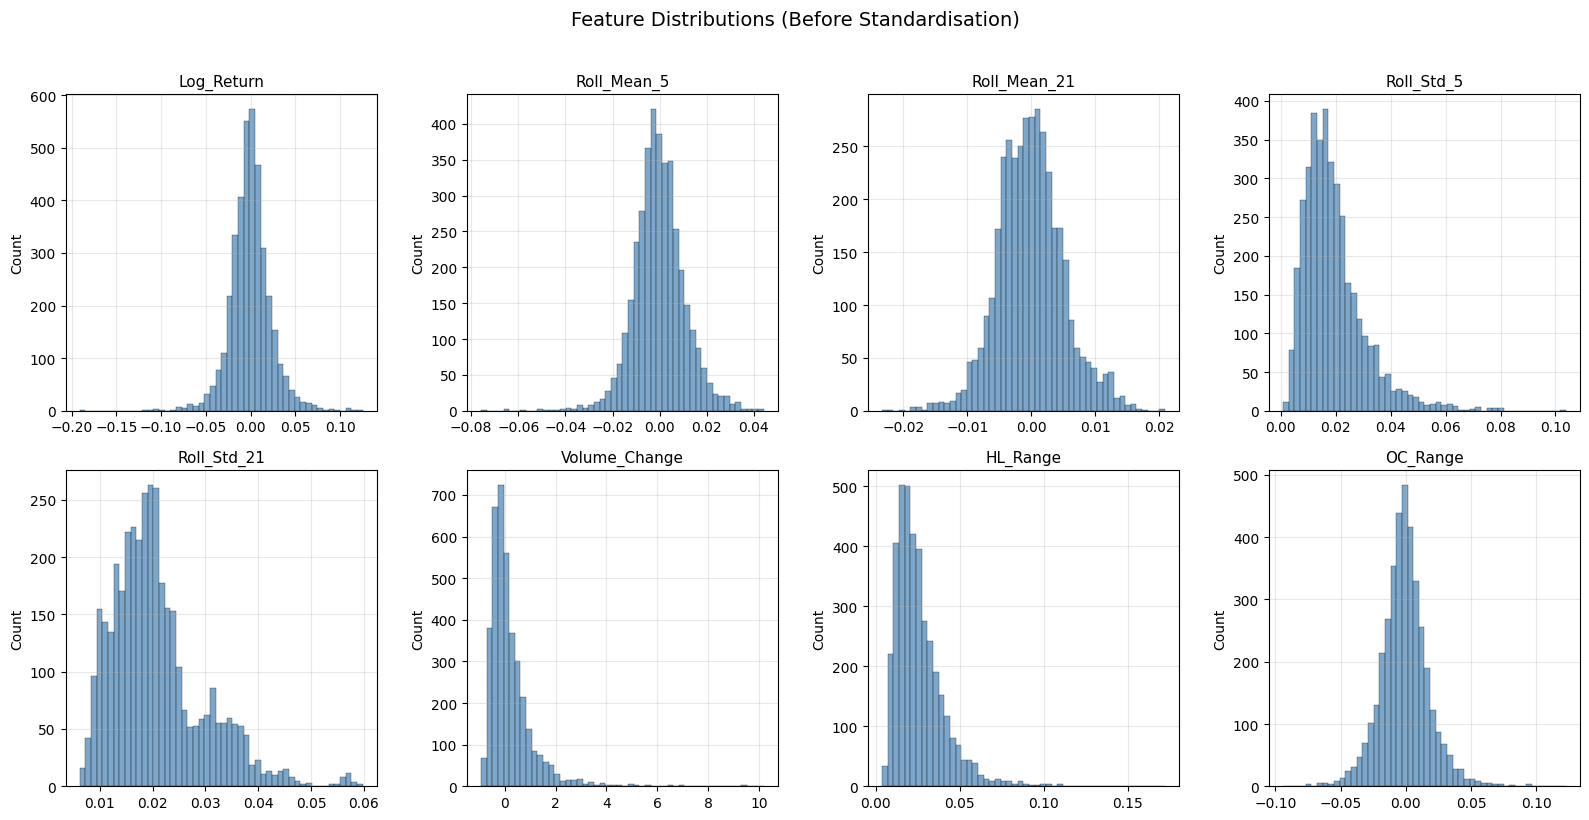

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df[col], bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions (Before Standardisation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 4.4 Chronological Train/Validation/Test Split and Standardisation

Since this is time-series data, we **cannot shuffle** the data randomly — doing so would introduce look-ahead bias. Instead, we split chronologically:

- **Training set**: first 70% of the data
- **Validation set**: next 15%
- **Test set**: final 15%

We then standardise (zero mean, unit variance) all input features using statistics computed **only on the training set**, and apply the same transformation to the validation and test sets. This prevents information leakage from future data.


In [ ]:
X = df[FEATURE_COLS].values
y = df['Target_Vol_21'].values

# Chronological split: 70% train, 15% val, 15% test
n = len(X)
if n == 0:
    raise ValueError('No rows remain after feature engineering. Check the downloaded data and rolling windows.')

train_split_idx = int(n * TRAIN_SPLIT)
val_split_idx = int(n * (TRAIN_SPLIT + VAL_SPLIT))

X_train_raw, y_train = X[:train_split_idx], y[:train_split_idx]
X_val_raw, y_val = X[train_split_idx:val_split_idx], y[train_split_idx:val_split_idx]
X_test_raw, y_test = X[val_split_idx:], y[val_split_idx:]

if 0 in (len(X_train_raw), len(X_val_raw), len(X_test_raw)):
    raise ValueError('Chronological split produced an empty train/validation/test set.')

# Store dates for plotting later
dates_train = df.index[:train_split_idx]
dates_val = df.index[train_split_idx:val_split_idx]
dates_test = df.index[val_split_idx:]

print(f"Training set:   {X_train_raw.shape[0]} samples ({dates_train[0].date()} to {dates_train[-1].date()})")
print(f"Validation set: {X_val_raw.shape[0]} samples ({dates_val[0].date()} to {dates_val[-1].date()})")
print(f"Test set:       {X_test_raw.shape[0]} samples ({dates_test[0].date()} to {dates_test[-1].date()})")

# Standardise features using training set statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"\nFeature means after scaling (train): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Feature stds after scaling (train):  {X_train_scaled.std(axis=0).round(4)}")


Training set:   2685 samples (2010-12-07 to 2021-08-06)
Validation set: 575 samples (2021-08-09 to 2023-11-17)
Test set:       576 samples (2023-11-20 to 2026-03-10)

Feature means after scaling (train): [ 0.  0.  0.  0. -0.  0.  0. -0.]
Feature stds after scaling (train):  [1. 1. 1. 1. 1. 1. 1. 1.]


### 4.5 Creating Sliding Window Sequences

LSTMs expect input in the shape `(samples, timesteps, features)`. We create sliding windows of 30 consecutive trading days as input, with the target being the 21-day forward realised volatility at the end of each window.

A window length of 30 days captures approximately 6 weeks of market history, giving the LSTM enough temporal context to learn volatility patterns while preserving a reasonable number of training samples.


In [ ]:
def create_sequences(X, y, window_size=30):
    """Create sliding window sequences for LSTM input."""
    if len(X) <= window_size:
        raise ValueError(
            f'Need more than {window_size} rows to create sequences, but received {len(X)}.'
        )

    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i - window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, WINDOW_SIZE)

print(f"Training sequences:   {X_train_seq.shape}  ->  {y_train_seq.shape}")
print(f"Validation sequences: {X_val_seq.shape}  ->  {y_val_seq.shape}")
print(f"Test sequences:       {X_test_seq.shape}  ->  {y_test_seq.shape}")
print(f"\nEach input sample: {WINDOW_SIZE} timesteps x {X_train_seq.shape[2]} features")


Training sequences:   (2655, 30, 8)  ->  (2655,)
Validation sequences: (545, 30, 8)  ->  (545,)
Test sequences:       (546, 30, 8)  ->  (546,)

Each input sample: 30 timesteps x 8 features


## 5. Network Architecture

### 5.1 Model Design

We use a stacked LSTM architecture with the following design choices:

- **Two LSTM layers** (64 and 32 units): The first layer returns sequences to feed into the second, allowing the network to learn hierarchical temporal features. The decreasing number of units acts as a bottleneck, forcing the network to compress its representation.
- **Dropout (0.2)** after each LSTM layer to regularise and reduce overfitting.
- **Dense output layer** with a single neuron and **linear activation**, appropriate for continuous regression — volatility is a positive real number with no upper bound.
- **Loss function**: Mean Squared Error (MSE), the standard choice for regression.
- **Optimiser**: Adam with default learning rate (0.001), which adapts the learning rate per-parameter and generally works well for RNNs.

**Why LSTM over vanilla RNN?** Standard RNNs suffer from the vanishing gradient problem, making it difficult to learn dependencies over long sequences. LSTMs use gating mechanisms (input, forget, output gates) that allow gradients to flow over many timesteps, making them well-suited for capturing the longer-term patterns in volatility data.


In [ ]:
n_features = X_train_seq.shape[2]

model = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(DROPOUT_RATE),
    LSTM(32, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Network Architecture Diagram

Below is a visual representation of the network architecture.


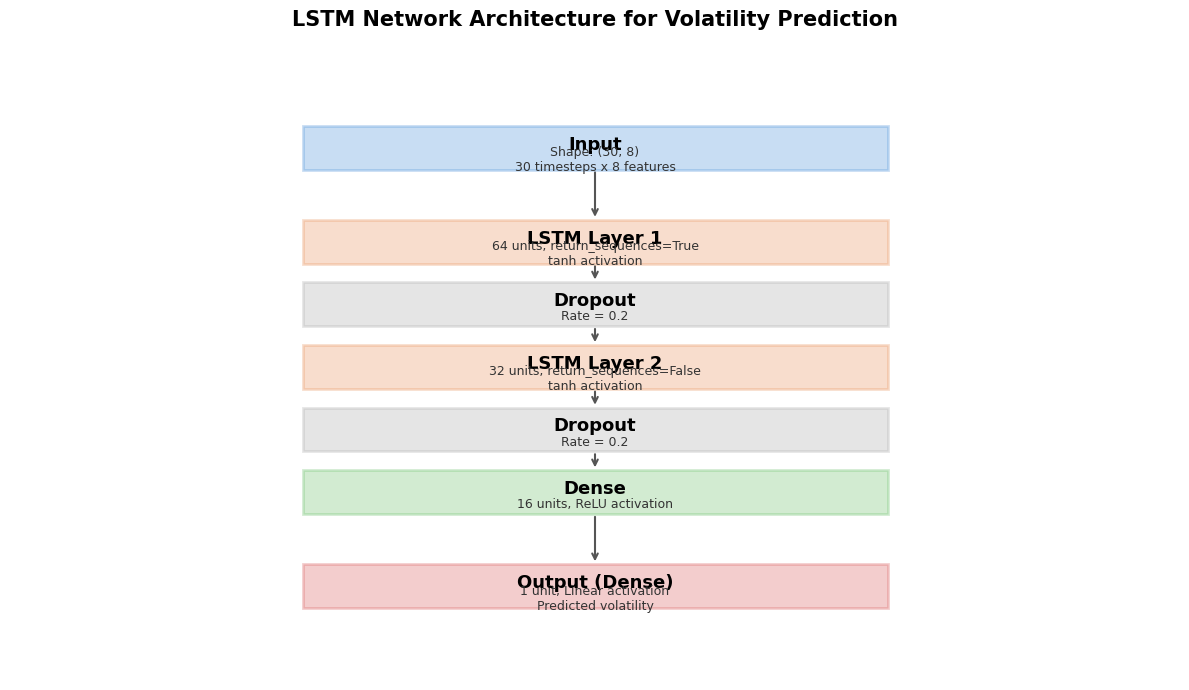

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Layer definitions: (y_position, label, details, color)
layers = [
    (8.5, 'Input', f'Shape: ({WINDOW_SIZE}, {n_features})\n{WINDOW_SIZE} timesteps x {n_features} features', '#4A90D9'),
    (7.0, 'LSTM Layer 1', '64 units, return_sequences=True\ntanh activation', '#E8915A'),
    (6.0, 'Dropout', f'Rate = {DROPOUT_RATE}', '#AAAAAA'),
    (5.0, 'LSTM Layer 2', '32 units, return_sequences=False\ntanh activation', '#E8915A'),
    (4.0, 'Dropout', f'Rate = {DROPOUT_RATE}', '#AAAAAA'),
    (3.0, 'Dense', '16 units, ReLU activation', '#6ABF69'),
    (1.5, 'Output (Dense)', '1 unit, Linear activation\nPredicted volatility', '#D95B5B'),
]

for y_pos, name, details, color in layers:
    box = plt.Rectangle((2.5, y_pos - 0.35), 5, 0.7, 
                          facecolor=color, alpha=0.3, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(5, y_pos + 0.05, name, ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(5, y_pos - 0.2, details, ha='center', va='center', fontsize=9, color='#333333')

# Arrows between layers
for i in range(len(layers) - 1):
    y_start = layers[i][0] - 0.35
    y_end = layers[i + 1][0] + 0.35
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

ax.set_title('LSTM Network Architecture for Volatility Prediction', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 6. Training

We train the network with the following strategy:

- **Batch size**: 32
- **Maximum epochs**: 150
- **Early stopping**: We monitor the validation loss and stop training if it does not improve for 15 consecutive epochs, restoring the weights from the best epoch. This is our primary defence against overfitting.

The training and validation loss curves are plotted below to verify that the network has converged and is not overfitting.


In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")


Epoch 1/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0013 - mae: 0.0234 - val_loss: 1.9376e-04 - val_mae: 0.0118
Epoch 2/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.2984e-04 - mae: 0.0077 - val_loss: 6.3464e-05 - val_mae: 0.0063
Epoch 3/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 8.1556e-05 - mae: 0.0061 - val_loss: 6.1650e-05 - val_mae: 0.0061
Epoch 4/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 7.8004e-05 - mae: 0.0059 - val_loss: 6.2120e-05 - val_mae: 0.0062
Epoch 5/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.1505e-05 - mae: 0.0057 - val_loss: 5.5553e-05 - val_mae: 0.0058
Epoch 6/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 6.5923e-05 - mae: 0.0055 - val_loss: 4.9307e-05 - val_mae: 0.0055
Epoch 7/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.3741e-05 - mae: 0.0054 - val_loss: 4.3563e-05 - val_mae: 0.0052
Epoch 8/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.2923e-05 - mae: 0.0053 - val_loss: 4.7449e-05 - val_mae: 0.0

### 6.1 Training and Validation Loss Curves

The plot below shows MSE loss on both the training and validation sets as a function of epoch. If the validation loss begins to increase while training loss continues to decrease, that indicates overfitting. Early stopping mitigates this by halting training and restoring the best weights.


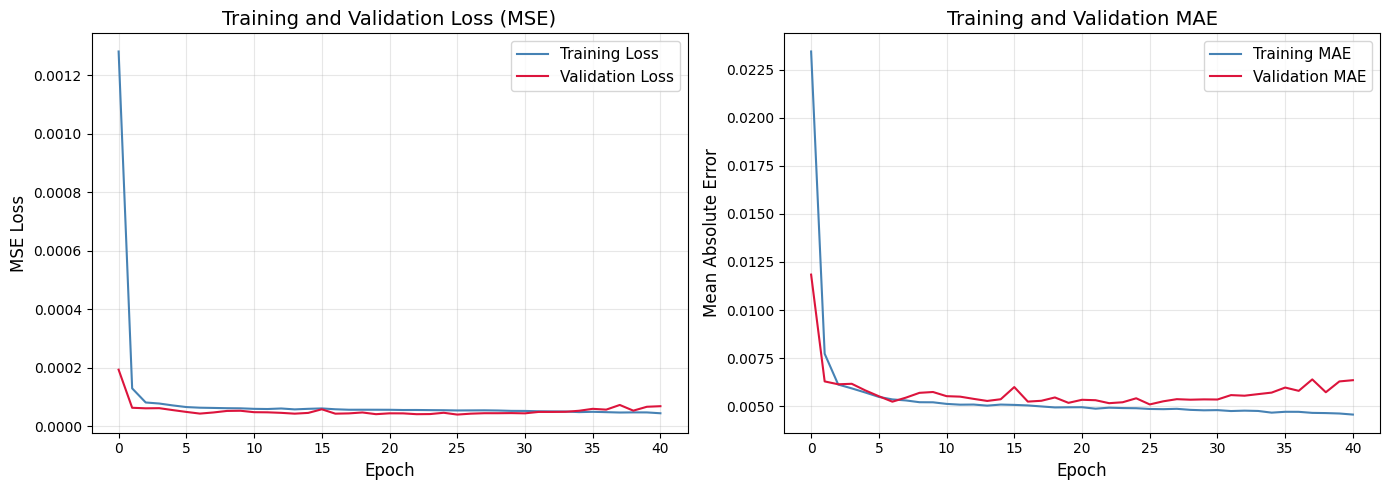

Final training loss:   0.000045
Final validation loss: 0.000069
Val/Train loss ratio:  1.54
Training and validation losses are reasonably close.


In [42]:
metric_key = 'mae' if 'mae' in history.history else 'mean_absolute_error'
val_metric_key = f'val_{metric_key}'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Loss
axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='crimson', linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss (MSE)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history[metric_key], label='Training MAE', color='steelblue', linewidth=1.5)
axes[1].plot(history.history[val_metric_key], label='Validation MAE', color='crimson', linewidth=1.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('Training and Validation MAE', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for overfitting
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
ratio = final_val_loss / final_train_loss
print(f"Final training loss:   {final_train_loss:.6f}")
print(f"Final validation loss: {final_val_loss:.6f}")
print(f"Val/Train loss ratio:  {ratio:.2f}")
if ratio > 2.0:
    print('Potential overfitting: validation loss is more than 2x training loss.')
else:
    print('Training and validation losses are reasonably close.')


## 7. Evaluation and Results

### 7.1 Predictions on the Test Set


In [43]:
# Generate predictions
y_pred_test = model.predict(X_test_seq).flatten()
y_pred_val = model.predict(X_val_seq).flatten()
y_pred_train = model.predict(X_train_seq).flatten()

# Compute metrics on test set
mse = mean_squared_error(y_test_seq, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_seq, y_pred_test)
r2 = r2_score(y_test_seq, y_pred_test)

print("=== Test Set Performance ===")
print(f"MSE:  {mse:.8f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
=== Test Set Performance ===
MSE:  0.00004891
RMSE: 0.006994
MAE:  0.005338
R²:   -0.1697


### 7.2 True vs Predicted Volatility (Scatter Plot)

In a perfect model, all points would lie on the diagonal $y = x$ line. Deviations from this line indicate prediction errors.


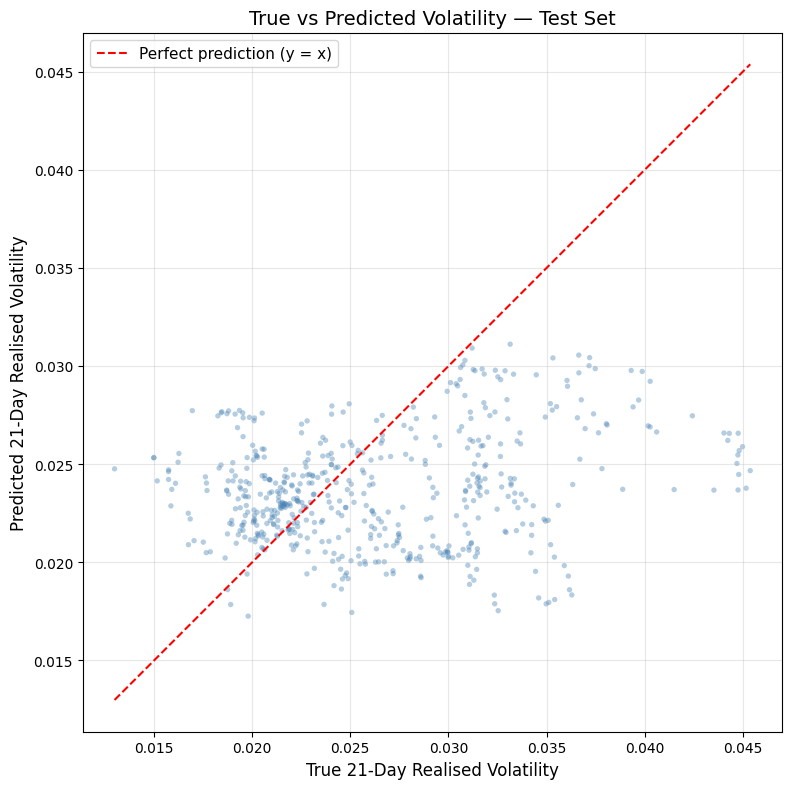

In [44]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test_seq, y_pred_test, alpha=0.4, s=15, color='steelblue', edgecolors='none')

# Plot y=x reference line
lims = [min(y_test_seq.min(), y_pred_test.min()), max(y_test_seq.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')

ax.set_xlabel('True 21-Day Realised Volatility', fontsize=12)
ax.set_ylabel('Predicted 21-Day Realised Volatility', fontsize=12)
ax.set_title('True vs Predicted Volatility — Test Set', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


### 7.3 Residual Differences

The residual plot shows the difference between true and predicted values. Ideally, residuals should be randomly scattered around zero with no systematic pattern.


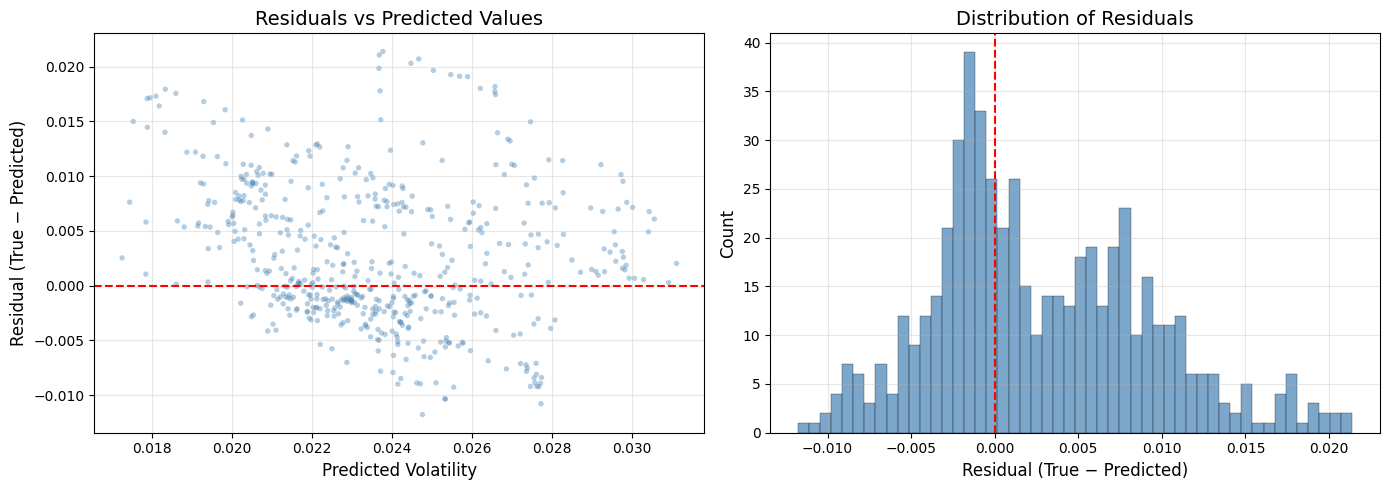

Residual mean:   0.002750
Residual std:    0.006430
Residual median: 0.001410


In [45]:
residuals = y_test_seq - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.4, s=15, color='steelblue', edgecolors='none')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Volatility', fontsize=12)
axes[0].set_ylabel('Residual (True − Predicted)', fontsize=12)
axes[0].set_title('Residuals vs Predicted Values', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (True − Predicted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean:   {residuals.mean():.6f}")
print(f"Residual std:    {residuals.std():.6f}")
print(f"Residual median: {np.median(residuals):.6f}")


### 7.4 Predicted vs True Volatility Over Time

This is perhaps the most informative plot — it overlays the predicted volatility on top of the true volatility across the test period. This allows us to visually assess whether the model captures the temporal dynamics, including regime changes and volatility spikes.


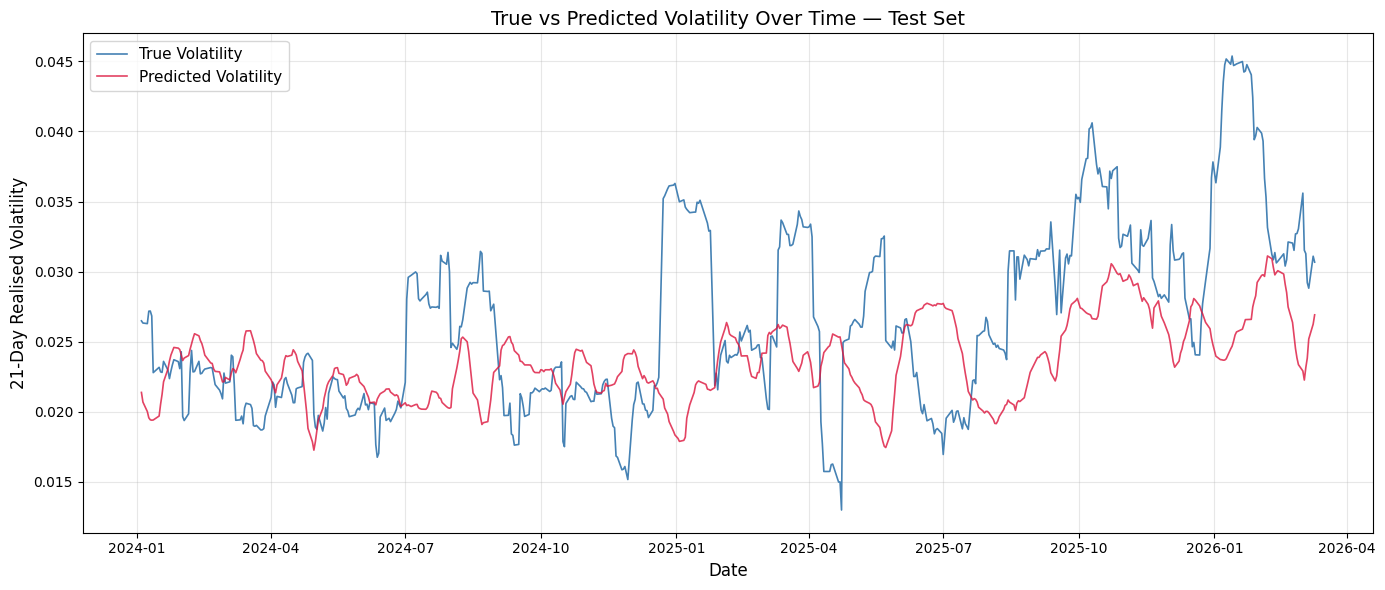

In [46]:
# Align dates with the sequences (we lose WINDOW_SIZE days from the start)
test_dates = dates_test[WINDOW_SIZE:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test_seq, label='True Volatility', color='steelblue', linewidth=1.2)
ax.plot(test_dates, y_pred_test, label='Predicted Volatility', color='crimson', linewidth=1.2, alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('21-Day Realised Volatility', fontsize=12)
ax.set_title('True vs Predicted Volatility Over Time — Test Set', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.5 Additional Performance Analysis — Rolling Window Metrics

To further assess the model's performance, we compute the R² score over a rolling 60-day window across the test set. This reveals whether the model performs consistently or if its accuracy varies across different market regimes.


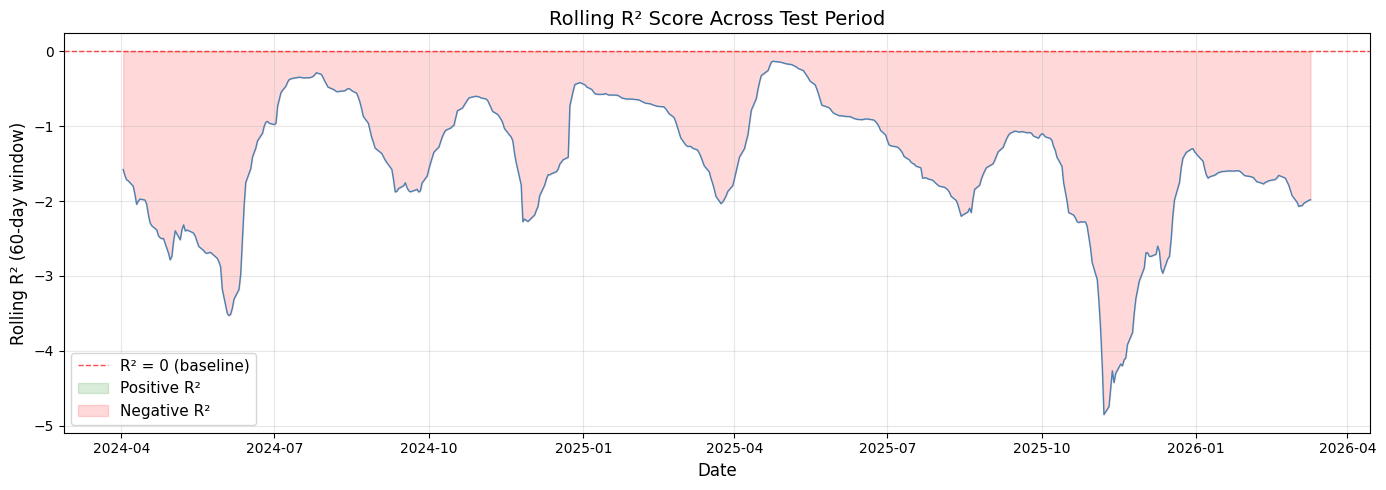

Mean rolling R²:   -1.4939
Median rolling R²: -1.4370
% of windows with positive R²: 0.0%


In [47]:
# Rolling R² over the test set
rolling_window = 60
rolling_r2 = []
rolling_dates = []

for i in range(rolling_window, len(y_test_seq)):
    window_true = y_test_seq[i - rolling_window:i]
    window_pred = y_pred_test[i - rolling_window:i]
    if np.std(window_true) > 0:
        r2_val = r2_score(window_true, window_pred)
        rolling_r2.append(r2_val)
        rolling_dates.append(test_dates[i])

if not rolling_r2:
    raise ValueError('Not enough test sequences to compute 60-day rolling R².')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_dates, rolling_r2, color='steelblue', linewidth=1.0)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='R² = 0 (baseline)')
ax.fill_between(rolling_dates, rolling_r2, 0, 
                where=[r > 0 for r in rolling_r2], alpha=0.15, color='green', label='Positive R²')
ax.fill_between(rolling_dates, rolling_r2, 0, 
                where=[r <= 0 for r in rolling_r2], alpha=0.15, color='red', label='Negative R²')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rolling R² (60-day window)', fontsize=12)
ax.set_title('Rolling R² Score Across Test Period', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean rolling R²:   {np.mean(rolling_r2):.4f}")
print(f"Median rolling R²: {np.median(rolling_r2):.4f}")
print(f"% of windows with positive R²: {100 * sum(1 for r in rolling_r2 if r > 0) / len(rolling_r2):.1f}%")


### 7.6 Summary of Results Across All Sets


In [48]:
# Compute metrics for all sets
sets = {
    'Training': (y_train_seq, y_pred_train),
    'Validation': (y_val_seq, y_pred_val),
    'Test': (y_test_seq, y_pred_test)
}

results = []
for name, (true, pred) in sets.items():
    results.append({
        'Set': name,
        'MSE': mean_squared_error(true, pred),
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': mean_absolute_error(true, pred),
        'R²': r2_score(true, pred)
    })

results_df = pd.DataFrame(results).set_index('Set')
print(results_df.to_string(float_format='{:.6f}'.format))


                MSE     RMSE      MAE        R²
Set                                            
Training   0.000052 0.007184 0.004613  0.243588
Validation 0.000040 0.006344 0.005096  0.352904
Test       0.000049 0.006994 0.005338 -0.169731


## 8. Conclusions

### 8.1 Summary

We designed and trained an LSTM-based recurrent neural network to predict the 21-day forward realised volatility of the Global X Uranium ETF (URA) using engineered features derived from daily OHLCV data sourced from Yahoo Finance.

### 8.2 Performance Assessment

The model's performance can be assessed through several lenses:

- **R² score**: Indicates what proportion of variance in the true volatility is explained by the model. A positive R² means the model outperforms a simple mean-prediction baseline.
- **True vs Predicted scatter plot**: Points clustering along the y=x line indicate good predictions.
- **Residuals**: Ideally centred around zero with no systematic bias.
- **Time-series overlay**: Shows whether the model tracks the temporal dynamics and captures regime changes.

### 8.3 Strengths and Limitations

**Strengths:**
- The LSTM architecture is well-suited to this sequential prediction task, as it can learn temporal dependencies in the volatility patterns.
- The chronological train/validation/test split avoids look-ahead bias, and standardisation is performed correctly using only training set statistics.
- Early stopping prevents overfitting while allowing the network to train for long enough.

**Limitations and potential improvements:**
- Volatility is inherently difficult to predict, and financial markets contain significant noise. Perfect prediction is not achievable.
- The model could be improved by incorporating additional external features such as macroeconomic indicators, uranium spot prices, or market-wide volatility indices (e.g. VIX).
- Attention mechanisms or Transformer-based architectures could potentially capture longer-range dependencies more effectively.
- Hyperparameter tuning (number of LSTM units, window size, learning rate, dropout rate) was done manually — a systematic search could yield better results.
- The dataset, while sufficient, is relatively small compared to what deep learning models typically require. A larger dataset or data augmentation strategies might improve generalisation.
